In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

import torch
import torch.nn as nn
import torch.nn.functional as F
import gc

from multiprocessing import Pool
import random
import seaborn as sns
from cosine_annealing_warmup import CosineAnnealingWarmupRestarts as CAWR

import torch
torch.set_default_dtype(torch.float64)

from util import *

In [2]:
signal_list  = [
    "B0_st",
    "cas_q_hl_32",
    "cas_c_hh_12",
    "lambcs_bc_32"]

signal = signal_list[2]
DATA_PATH = "../../../CorrelatorStudy/Bdata/ext2/"
f = open(f"{DATA_PATH}/{signal}", "r")
data = f.readlines()
f.close()

y_raw = np.array(list(map(lambda x: abs(float(x.split("\t")[-1].split("\n")[0])), data)), dtype=float)
x_raw = np.array(list(map(lambda x: float(x.split("\t")[0].split("\n")[0]), data)), dtype=float)



In [3]:
gs_energy_mean_B = []
gs_energy_mean_N = []

gs_energy_std_B = []
gs_energy_std_N = []

_percent_B_converged = []
_percent_N_converged = []

_percent_B_distinct = []
_percent_N_distinct = []


for CUT in tqdm(range(0,20)):
    idx = (x_raw>=0)
    x = x_raw[idx]
    y = y_raw[idx]
    
    log_y = np.log(y)
    reg = LinearRegression(fit_intercept=True,n_jobs=1).fit(x.reshape(-1, 1), log_y)
    y_pred = reg.predict(x.reshape(-1, 1))
    error_se = np.mean((log_y-y_pred)**2)
    
    
    device = "cuda:0"
    BATCH_SIZE = 512
    noise_dim = 64
    model = Guess(feature_size=noise_dim,
                  mul=4,
                  nparam=4)
    
    model = model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(),lr = 1e-3)
    
    
    x_tensor = torch.tensor(x,device=device,dtype=torch.float64)
    y_tensor = torch.tensor(y,device=device,dtype=torch.float64)
    
    model = train_guess_network(model=model,
                                x_tensor=x_tensor,
                                y_tensor=y_tensor,
                                NEpochs=10_000,
                                optimizer=optimizer,
                                BATCH_SIZE=BATCH_SIZE,
                                noise_dim=noise_dim,
                                device=device,
                                verbose=False)
    
    
    
    model = model.to("cpu")
    B,NG = iterate_through_noise(x=x,
                                 y=y,
                                 nsamples=256,
                              noise_dim=64,
                              model=model,
                              fit_func=double_exponential)
    
    B_distinct = []
    B_collapsed = []
    
    NG_distinct = []
    NG_collapsed = []
    
    
    for elem_B in B:
        if elem_B[-1]<error_se:
            B_distinct.append(elem_B[0])
        else:
            B_collapsed.append(elem_B[0])
    
    for elem_NG in NG:
        if elem_NG[-1]<error_se:
            NG_distinct.append(elem_NG[0])
        else:
            NG_collapsed.append(elem_NG[0])
    
    
    N_B_converged = len(B)
    N_NG_converged = len(NG)
    
    N_B_distinct = len(B_distinct)
    N_B_collapsed = len(B_collapsed)
    
    N_NG_distinct = len(NG_distinct)
    N_NG_collapsed = len(NG_collapsed)



    _percent_B_converged.append(100*(N_B_converged/256))
    _percent_N_converged.append(100*(N_NG_converged/256))

    _percent_B_distinct.append(100*(N_B_distinct/N_B_converged))
    _percent_N_distinct.append(100*(N_NG_distinct/N_NG_converged))
    
    
    param_B_distinct = np.array(B_distinct)
    param_B_collapsed = np.array(B_collapsed)
    
    param_NG_distinct = np.array(NG_distinct)
    param_NG_collapsed = np.array(NG_collapsed)
    
    
    param_B_distinct.sort(-1)
    param_NG_distinct.sort(-1)
    
    gs_energy_mean_B.append(param_B_distinct[:,0].mean())
    gs_energy_mean_N.append(param_NG_distinct[:,0].mean())
        
    gs_energy_std_B.append(param_B_distinct[:,0].std()/np.sqrt(param_B_distinct.shape[0]))
    gs_energy_std_N.append(param_NG_distinct[:,0].std()/np.sqrt(param_NG_distinct.shape[0]))

  0%|          | 0/20 [00:00<?, ?it/s]

/pscratch/sd/d/diptarko/Thesis/fyear/main/thesis/Refactory/Ground-State-Extraction/LMA-NG/util.py:92: RuntimeWarning: invalid value encountered in log
  return np.log(a * np.exp(-E0 * t) + b * np.exp(-E1 * t))
/pscratch/sd/d/diptarko/Thesis/fyear/main/thesis/Refactory/Ground-State-Extraction/LMA-NG/util.py:92: RuntimeWarning: overflow encountered in exp
  return np.log(a * np.exp(-E0 * t) + b * np.exp(-E1 * t))
/pscratch/sd/d/diptarko/Thesis/fyear/main/thesis/Refactory/Ground-State-Extraction/LMA-NG/util.py:123: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_double_Baseline, cov2 = curve_fit(fit_func, x, np.log(y), p0=n, method="lm")
/pscratch/sd/d/diptarko/Thesis/fyear/main/thesis/Refactory/Ground-State-Extraction/LMA-NG/util.py:92: RuntimeWarning: overflow encountered in multiply
  return np.log(a * np.exp(-E0 * t) + b * np.exp(-E1 * t))
/pscratch/sd/d/diptarko/Thesis/fyear/main/thesis/Refactory/Ground-State-Extraction/LMA-NG/util.py:117: OptimizeWarning:

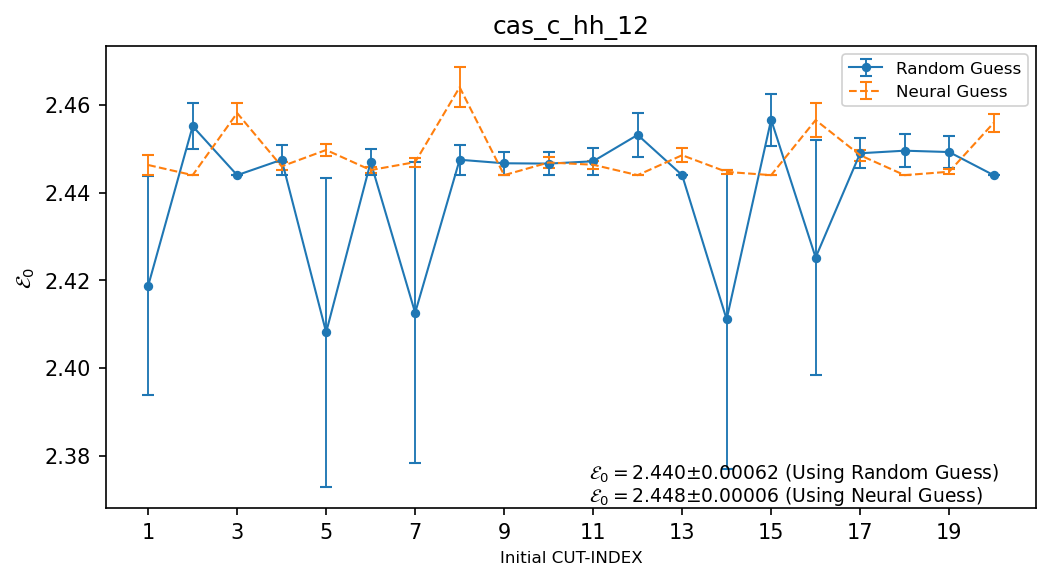

In [10]:
plot_x = list(range(0,20))
handles = []
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8, 4),dpi=150)
h = ax.errorbar(plot_x,gs_energy_mean_B,yerr=gs_energy_std_B,
            fmt="o-", capsize=3, linewidth=1.0, elinewidth=0.9,
            markersize=3.5, alpha=1, label="Random Guess",color = "tab:blue")
handles.append(h)

h2 = ax.errorbar(plot_x,gs_energy_mean_N,yerr=gs_energy_std_N,
            fmt="--", capsize=3, linewidth=1.0, elinewidth=0.9,
            markersize=3.5, alpha=1, label="Neural Guess",color = "tab:orange")
handles.append(h2)


ax.set_xticks(plot_x[::2])
ax.set_xticklabels((np.array(plot_x)[::2] + 1).tolist())

ax.set_xlabel("Initial CUT-INDEX", fontsize=8)
ax.set_ylabel(r"$\mathcal{E}_0$", fontsize=10)

    
leg = ax.legend(loc="upper right", frameon=True, ncol=1,fontsize=8)
leg.get_frame().set_alpha(0.9)
leg.get_frame().set_linewidth(0.8)


mean_energy_Baseline = np.array(gs_energy_mean_B).mean()
std_error_Baseline = np.sum(np.array(gs_energy_std_B).std()**2)**0.5/len(gs_energy_std_B)
mean_energy_NeuralGuess = np.array(gs_energy_mean_N).mean()
std_error_NeuralGuess = np.sum(np.array(gs_energy_std_N).std()**2)**0.5/len(gs_energy_std_N)


ax.text(0.52,
        0.05,
        (r"$\mathcal{E}_0=$"+f"{mean_energy_NeuralGuess:.3f}"+r"$\pm$"+f"{std_error_NeuralGuess:.5f}" +" (Using Neural Guess)"),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9)

ax.text(0.52,
        0.10,
        (r"$\mathcal{E}_0=$"+f"{mean_energy_Baseline:.3f}"+r"$\pm$"+f"{std_error_Baseline:.5f}" +" (Using Random Guess)"),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9)
plt.title(signal)
plt.savefig("../assets/LMA_NG_c.png")
plt.show()